# Hydraulic System Fault Classifier — UCI Dataset
**Digital Systems Project — UWE Bristol**

This notebook trains XGBoost fault classifiers for the hydraulic monitoring side of the predictive maintenance platform. It is the second ML stream alongside the bearing anomaly detection work (NASA IMS dataset).

The hydraulic extension was added because the IMS dataset only has three bearing failures total, which makes proper cross-validated fault classification impossible. The UCI Hydraulic Systems dataset solves this — 2,205 fully labelled cycles across four components, with enough examples per condition state for leave-one-out validation to work properly.

Three model bundles are trained (one per simulated hydraulic unit), each containing four XGBoost classifiers — one per component.

---
## 0. Imports

In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, accuracy_score, ConfusionMatrixDisplay
)
from sklearn.utils.class_weight import compute_class_weight
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')

import sklearn, xgboost
print(f'scikit-learn : {sklearn.__version__}')
print(f'xgboost      : {xgboost.__version__}')
print(f'numpy        : {np.__version__}')

scikit-learn : 1.6.1
xgboost      : 3.0.0
numpy        : 1.26.4


In [2]:
# Paths — notebook lives in 01_model_development/, data is one level up
ROOT       = Path('../')
HYDRAULIC  = ROOT / 'hydraulic_data'
OUTPUT_DIR = Path('results/hydraulic_classifier')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Each sensor file contains one row per cycle (2205 rows)
# and one column per time point within that cycle
# Sampling rates vary: PS/EPS1 at 100Hz (6000 pts), FS at 10Hz (600 pts), rest at 1Hz (60 pts)
SENSORS = [
    ('PS1',  'Pressure bar',        100, 6000),
    ('PS2',  'Pressure bar',        100, 6000),
    ('PS3',  'Pressure bar',        100, 6000),
    ('PS4',  'Pressure bar',        100, 6000),
    ('PS5',  'Pressure bar',        100, 6000),
    ('PS6',  'Pressure bar',        100, 6000),
    ('EPS1', 'Motor power W',       100, 6000),
    ('FS1',  'Volume flow l/min',    10,  600),
    ('FS2',  'Volume flow l/min',    10,  600),
    ('TS1',  'Temperature C',         1,   60),
    ('TS2',  'Temperature C',         1,   60),
    ('TS3',  'Temperature C',         1,   60),
    ('TS4',  'Temperature C',         1,   60),
    ('VS1',  'Vibration mm/s',        1,   60),
    ('CE',   'Cooling efficiency %',  1,   60),
    ('CP',   'Cooling power kW',      1,   60),
    ('SE',   'System efficiency %',   1,   60),
]
SENSOR_NAMES = [s[0] for s in SENSORS]

# Columns in profile.txt (tab-separated, no header)
TARGET_COLS = ['cooler', 'valve', 'pump', 'accumulator', 'stable']
COMPONENTS  = ['cooler', 'valve', 'pump', 'accumulator']

# Human-readable labels for each component's condition values
COMPONENT_LABELS = {
    'cooler':      {3: 'Near failure', 20: 'Reduced', 100: 'Full efficiency'},
    'valve':       {73: 'Near failure', 80: 'Severe lag', 90: 'Small lag', 100: 'Optimal'},
    'pump':        {0: 'No leakage', 1: 'Weak leakage', 2: 'Severe leakage'},
    'accumulator': {90: 'Near failure', 100: 'Severely reduced',
                    115: 'Slightly reduced', 130: 'Optimal'},
}

np.random.seed(42)
print('Config OK')
print(f'Sensors  : {len(SENSORS)}')
print(f'Data dir : {HYDRAULIC.resolve()}')

Config OK
Sensors  : 17
Data dir : C:\Users\Charl\Desktop\Bsc Computer Science\Year 3\DigitalSystemProject\cnc-predictive-maintenance\hydraulic_data


---
## 1. Load Sensor Data

17 sensor files, each with 2205 rows (one per cycle). The PS and EPS1 files sample at 100Hz so they are large — this cell takes around 30 seconds to run.

In [3]:
print('Loading sensor files...')
raw_sensors = {}
for name, desc, hz, pts in SENSORS:
    filepath = HYDRAULIC / f'{name}.txt'
    df = pd.read_csv(filepath, sep='\t', header=None)
    assert df.shape == (2205, pts), f'{name}: expected (2205, {pts}), got {df.shape}'
    raw_sensors[name] = df
    print(f'  {name:<5} {desc:<25} shape={df.shape}')

print('\nLoading labels (profile.txt)...')
profile = pd.read_csv(HYDRAULIC / 'profile.txt', sep='\t', header=None,
                      names=TARGET_COLS)
print(f'  shape={profile.shape}')
print(profile.head())

Loading sensor files...
  PS1   Pressure bar              shape=(2205, 6000)
  PS2   Pressure bar              shape=(2205, 6000)
  PS3   Pressure bar              shape=(2205, 6000)
  PS4   Pressure bar              shape=(2205, 6000)
  PS5   Pressure bar              shape=(2205, 6000)
  PS6   Pressure bar              shape=(2205, 6000)
  EPS1  Motor power W             shape=(2205, 6000)
  FS1   Volume flow l/min         shape=(2205, 600)
  FS2   Volume flow l/min         shape=(2205, 600)
  TS1   Temperature C             shape=(2205, 60)
  TS2   Temperature C             shape=(2205, 60)
  TS3   Temperature C             shape=(2205, 60)
  TS4   Temperature C             shape=(2205, 60)
  VS1   Vibration mm/s            shape=(2205, 60)
  CE    Cooling efficiency %      shape=(2205, 60)
  CP    Cooling power kW          shape=(2205, 60)
  SE    System efficiency %       shape=(2205, 60)

Loading labels (profile.txt)...
  shape=(2205, 5)
   cooler  valve  pump  accumulator  stabl

---
## 2. Feature Extraction

Each sensor's time series per cycle is summarised with five statistics: mean, std, max, min, range. That gives 17 sensors × 5 = 85 features per cycle.

A simple statistical feature set like this is a reasonable starting point for XGBoost on tabular data — the model can find discriminative combinations across sensors without needing raw time series.

In [4]:
print('Extracting features (mean, std, max, min, range per sensor per cycle)...')
feature_rows = []

for cycle_idx in range(2205):
    row = {}
    for name, _, _, _ in SENSORS:
        vals = raw_sensors[name].iloc[cycle_idx].values.astype(np.float64)
        row[f'{name}_mean']  = np.mean(vals)
        row[f'{name}_std']   = np.std(vals)
        row[f'{name}_max']   = np.max(vals)
        row[f'{name}_min']   = np.min(vals)
        row[f'{name}_range'] = np.max(vals) - np.min(vals)
    feature_rows.append(row)

features_df   = pd.DataFrame(feature_rows)
FEATURE_NAMES = list(features_df.columns)

print(f'Feature matrix : {features_df.shape}  (cycles x features)')
print(f'Features/cycle : {len(FEATURE_NAMES)}')
print(f'Example cols   : {FEATURE_NAMES[:8]}')

Extracting features (mean, std, max, min, range per sensor per cycle)...
Feature matrix : (2205, 85)  (cycles x features)
Features/cycle : 85
Example cols   : ['PS1_mean', 'PS1_std', 'PS1_max', 'PS1_min', 'PS1_range', 'PS2_mean', 'PS2_std', 'PS2_max']


---
## 3. Filter and Encode Targets

The `stable` column flags cycles where the rig had not reached steady state. Those are excluded — they don't cleanly represent any single condition. Of 2205 total cycles, 1449 are stable.

Each component's condition values are integer-encoded with LabelEncoder ready for XGBoost.

In [5]:
# Keep only stable cycles
stable_mask = profile['stable'] == 0
print(f'Total cycles     : 2205')
print(f'Stable cycles    : {stable_mask.sum()}')
print(f'Unstable excluded: {(~stable_mask).sum()}')

features_stable = features_df[stable_mask].reset_index(drop=True)
profile_stable  = profile[stable_mask].reset_index(drop=True)

encoders = {}
targets  = {}

for component in COMPONENTS:
    le = LabelEncoder()
    encoded = le.fit_transform(profile_stable[component])
    encoders[component] = le
    targets[component]  = encoded
    print(f'\n{component}:')
    for cls_int, cls_val in enumerate(le.classes_):
        label = COMPONENT_LABELS[component].get(int(cls_val), str(cls_val))
        count = np.sum(encoded == cls_int)
        print(f'  class {cls_int} = {int(cls_val):>4}  "{label}"  ({count} cycles)')

Total cycles     : 2205
Stable cycles    : 1449
Unstable excluded: 756

cooler:
  class 0 =    3  "Near failure"  (480 cycles)
  class 1 =   20  "Reduced"  (480 cycles)
  class 2 =  100  "Full efficiency"  (489 cycles)

valve:
  class 0 =   73  "Near failure"  (360 cycles)
  class 1 =   80  "Severe lag"  (360 cycles)
  class 2 =   90  "Small lag"  (360 cycles)
  class 3 =  100  "Optimal"  (369 cycles)

pump:
  class 0 =    0  "No leakage"  (489 cycles)
  class 1 =    1  "Weak leakage"  (480 cycles)
  class 2 =    2  "Severe leakage"  (480 cycles)

accumulator:
  class 0 =   90  "Near failure"  (369 cycles)
  class 1 =  100  "Severely reduced"  (360 cycles)
  class 2 =  115  "Slightly reduced"  (360 cycles)
  class 3 =  130  "Optimal"  (360 cycles)


---
## 4. Quick Data Check

Two things worth checking before training: class balance across components, and whether the sensor features actually separate the condition states. If the histograms overlap completely, those sensors won't help the classifier.

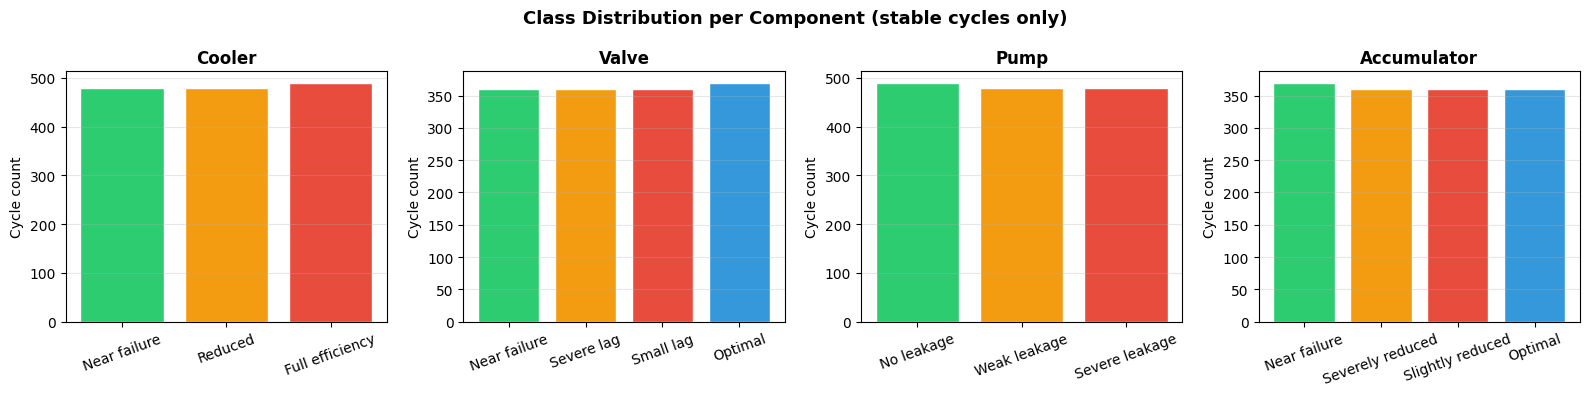

Saved: class_distributions.png


In [6]:
# Class balance per component
# Expecting roughly equal counts since the dataset was designed with systematic variation
colours = ['#2ecc71', '#f39c12', '#e74c3c', '#3498db']

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle('Class Distribution per Component (stable cycles only)',
             fontsize=13, fontweight='bold')

for ax, component in zip(axes, COMPONENTS):
    le      = encoders[component]
    encoded = targets[component]
    counts  = [np.sum(encoded == i) for i in range(len(le.classes_))]
    labels  = [COMPONENT_LABELS[component].get(int(v), str(v)) for v in le.classes_]
    ax.bar(labels, counts, color=colours[:len(counts)], edgecolor='white')
    ax.set_title(component.capitalize(), fontweight='bold')
    ax.set_ylabel('Cycle count')
    ax.tick_params(axis='x', rotation=20)
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'class_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: class_distributions.png')

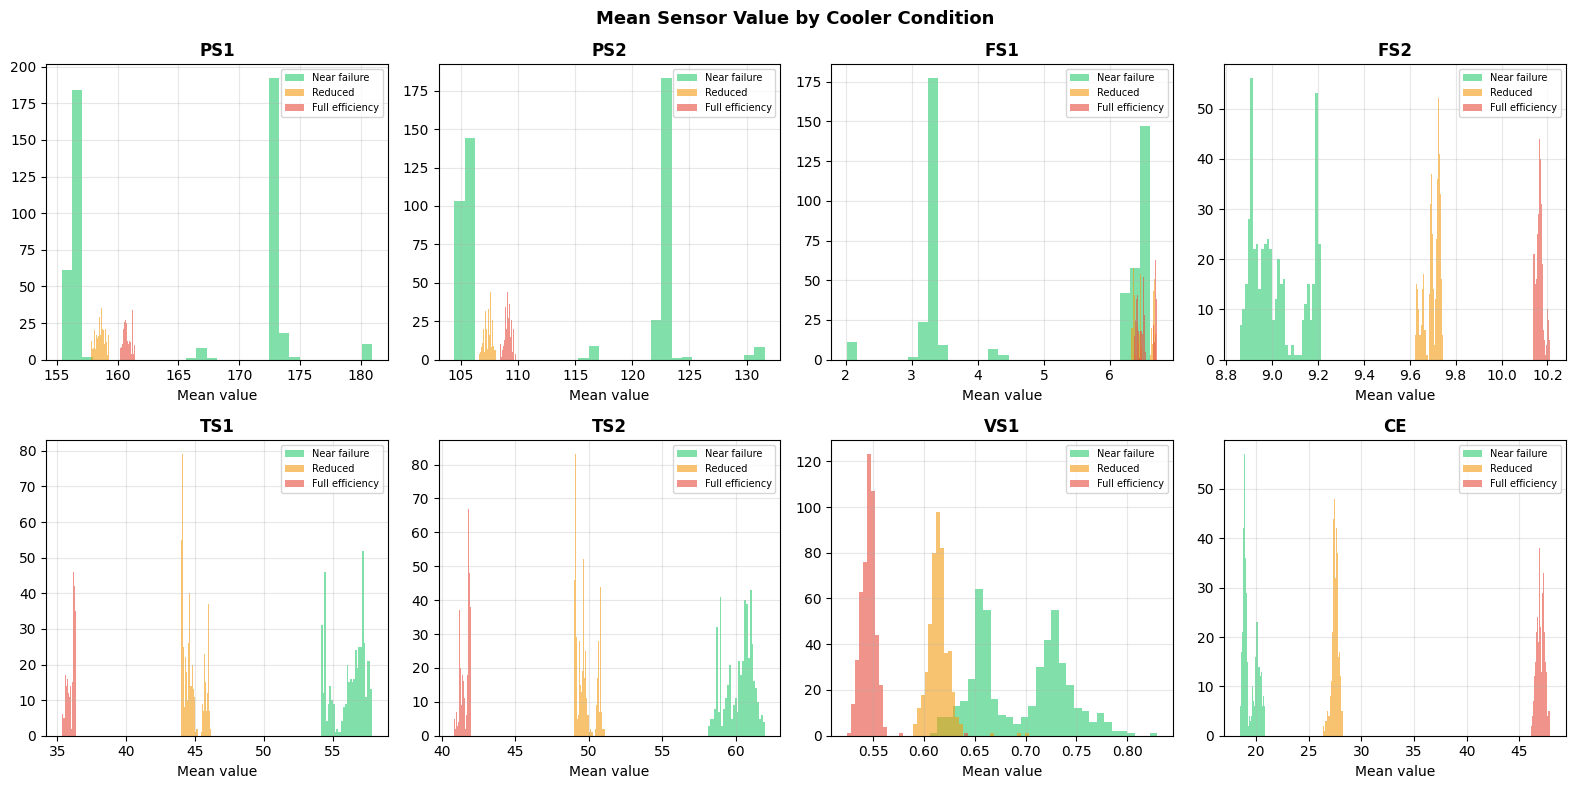

Saved: sensor_distributions_by_cooler.png


In [7]:
# Sensor distributions split by cooler condition
# If the histograms overlap heavily, those sensors won't help the cooler classifier
# Clear separation = strong discriminative features
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Mean Sensor Value by Cooler Condition',
             fontsize=13, fontweight='bold')

plot_sensors = ['PS1', 'PS2', 'FS1', 'FS2', 'TS1', 'TS2', 'VS1', 'CE']
cooler_enc   = targets['cooler']
cooler_le    = encoders['cooler']

for ax, sensor in zip(axes.flat, plot_sensors):
    sensor_mean = features_stable[f'{sensor}_mean'].values
    for cls_int, cls_val in enumerate(cooler_le.classes_):
        mask  = cooler_enc == cls_int
        label = COMPONENT_LABELS['cooler'].get(int(cls_val), str(cls_val))
        ax.hist(sensor_mean[mask], bins=30, alpha=0.6,
                label=label, color=colours[cls_int])
    ax.set_title(sensor, fontweight='bold')
    ax.set_xlabel('Mean value')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'sensor_distributions_by_cooler.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: sensor_distributions_by_cooler.png')

In [8]:
def train_xgb_component(X_train, y_train):
    """Train XGBoost with contiguous label remapping and balanced sample weights."""
    train_classes  = np.unique(y_train)
    local_map      = {orig: local for local, orig in enumerate(train_classes)}
    inverse_map    = {local: orig for orig, local in local_map.items()}
    y_local        = np.array([local_map[c] for c in y_train])

    cw             = compute_class_weight('balanced', classes=np.unique(y_local), y=y_local)
    weight_map     = dict(enumerate(cw))
    sample_weights = np.array([weight_map[c] for c in y_local])

    model = XGBClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='mlogloss',
        random_state=42,
        verbosity=0
    )
    model.fit(X_train, y_local, sample_weight=sample_weights)
    model._local_to_global = inverse_map
    return model


def predict_xgb(model, X):
    """Predict using global class labels."""
    local_pred = model.predict(X)
    return np.array([model._local_to_global[p] for p in local_pred])

---
## 5. Model Comparison

Before committing to XGBoost, it is worth checking whether simpler models can do the job. Three classifiers are compared on the same LOO folds:

- **Logistic Regression** — simple linear baseline
- **Random Forest** — tree ensemble, similar family to XGBoost but no boosting
- **XGBoost** — gradient boosted trees

The comparison uses the **valve** component rather than cooler. Cooler only has two condition states in the stable cycles and all three models achieve perfect F1 on it — it is too easy to be a useful discriminator. Valve has four condition levels with fuzzy boundaries between adjacent grades, which is where the differences between models actually show up.

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.base import clone

# Model comparison — valve component (hardest: 4 classes, fine-grained boundaries)
print('Model comparison — Valve component, LOO folds')
print('=' * 60)
print(f'  {"Model":<25} {"H1 F1":>8} {"H2 F1":>8} {"H3 F1":>8} {"Mean":>8}')
print('-' * 60)

X_all    = features_stable[FEATURE_NAMES].values
N        = len(features_stable)
fold     = N // 3
rng      = np.random.default_rng(42)
shuffled = rng.permutation(N)

fold_0 = shuffled[0:fold]
fold_1 = shuffled[fold:2*fold]
fold_2 = shuffled[2*fold:]

loo_splits_quick = [
    ('H1', fold_0, np.concatenate([fold_1, fold_2])),
    ('H2', fold_1, np.concatenate([fold_0, fold_2])),
    ('H3', fold_2, np.concatenate([fold_0, fold_1])),
]

classifiers = [
    ('Logistic Regression', LogisticRegression(max_iter=1000, random_state=42)),
    ('Random Forest',       RandomForestClassifier(n_estimators=100, random_state=42)),
    ('XGBoost',             'xgb'),
]

y_valve = targets['valve']

for clf_name, clf in classifiers:
    fold_f1s = []
    for fold_name, val_idx, train_idx in loo_splits_quick:
        scaler  = StandardScaler()
        X_train = scaler.fit_transform(X_all[train_idx])
        X_val   = scaler.transform(X_all[val_idx])
        y_train = y_valve[train_idx]
        y_val   = y_valve[val_idx]

        if clf == 'xgb':
            model    = train_xgb_component(X_train, y_train)
            val_pred = predict_xgb(model, X_val)
        else:
            model = clone(clf)
            model.fit(X_train, y_train)
            val_pred = model.predict(X_val)

        f1 = f1_score(y_val, val_pred, average='macro', zero_division=0)
        fold_f1s.append(f1)

    print(f'  {clf_name:<25} {fold_f1s[0]:>8.4f} {fold_f1s[1]:>8.4f} {fold_f1s[2]:>8.4f} {np.mean(fold_f1s):>8.4f}')

print('=' * 60)

Model comparison — Valve component, LOO folds
  Model                        H1 F1    H2 F1    H3 F1     Mean
------------------------------------------------------------
  Logistic Regression         0.7740   0.7682   0.7941   0.7788
  Random Forest               0.9478   0.9661   0.9594   0.9577
  XGBoost                     0.9753   0.9685   0.9673   0.9704


### Model Selection

Based on the results above, **XGBoost is selected** for the final models.

The valve component is the hardest classification task in the dataset — four condition levels with fine-grained boundaries between adjacent grades — so it is where model differences actually show up. On cooler, all three models achieve perfect F1, which tells us nothing useful about which is better.

Logistic Regression achieves a mean F1 of 0.779 across the three folds. That is a reasonable result for a linear model, but the gap to the tree-based approaches is large enough to confirm that the relationship between sensor statistics and valve condition is not linear. A linear model is not sufficient here.

Random Forest (mean F1 = 0.958) performs substantially better and would be a defensible choice. XGBoost (mean F1 = 0.970) edges it out by around 0.012 mean F1 points. That gap is small but consistent across all three folds, which suggests it is real rather than noise. XGBoost's boosting mechanism focuses successive trees on the misclassified boundary cases — exactly the adjacent-grade confusions that make the valve component hard — which explains the advantage over Random Forest.

Given the consistent improvement across all folds, XGBoost is the justified choice for the final models.

---
## 6. Leave-One-Out Training

Three models are trained, one per simulated hydraulic unit, using leave-one-out cross-validation at the cycle level.

**One important data issue:** the UCI dataset records condition states in systematic blocks. Splitting by raw index would give each fold almost entirely one class, which would make results meaningless. The fix is to shuffle the cycle indices with a fixed random seed (42) before splitting — each fold then sees a representative mix of all conditions and results are still reproducible.

**Label remapping:** XGBoost requires class labels starting from 0 with no gaps. The helper function handles this remapping locally per model.

In [10]:
def train_xgb_component(X_train, y_train):
    """Train XGBoost with contiguous label remapping and balanced sample weights."""
    train_classes  = np.unique(y_train)
    local_map      = {orig: local for local, orig in enumerate(train_classes)}
    inverse_map    = {local: orig for orig, local in local_map.items()}
    y_local        = np.array([local_map[c] for c in y_train])

    cw             = compute_class_weight('balanced', classes=np.unique(y_local), y=y_local)
    weight_map     = dict(enumerate(cw))
    sample_weights = np.array([weight_map[c] for c in y_local])

    model = XGBClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='mlogloss',
        random_state=42,
        verbosity=0
    )
    model.fit(X_train, y_local, sample_weight=sample_weights)
    model._local_to_global = inverse_map
    return model


def predict_xgb(model, X):
    """Predict using global class labels."""
    local_pred = model.predict(X)
    return np.array([model._local_to_global[p] for p in local_pred])


# --- Build LOO splits ---
# Shuffle cycle indices before splitting to break systematic block ordering
N        = len(features_stable)
fold     = N // 3
rng      = np.random.default_rng(42)
shuffled = rng.permutation(N)

fold_0 = shuffled[0:fold]       # -> H1 validation set
fold_1 = shuffled[fold:2*fold]  # -> H2 validation set
fold_2 = shuffled[2*fold:]      # -> H3 validation set

LOO_SPLITS = [
    ('Model_H1', 'Hydraulic Unit 1', fold_0, np.concatenate([fold_1, fold_2])),
    ('Model_H2', 'Hydraulic Unit 2', fold_1, np.concatenate([fold_0, fold_2])),
    ('Model_H3', 'Hydraulic Unit 3', fold_2, np.concatenate([fold_0, fold_1])),
]

print(f'Stable cycles : {N}')
print(f'Fold size     : ~{fold}')
print()

# Quick sanity check — each fold should have ~equal class counts
print('Class balance check per fold (cooler):')
cooler_enc = targets['cooler']
for name, _, val_idx, _ in LOO_SPLITS:
    counts = [np.sum(cooler_enc[val_idx] == c) for c in range(3)]
    print(f'  {name}: near-failure={counts[0]}, reduced={counts[1]}, full={counts[2]}')
print()

# --- Train ---
X_all       = features_stable[FEATURE_NAMES].values
loo_results = {}

for model_name, unit_name, val_idx, train_idx in LOO_SPLITS:
    print(f'{model_name} ({unit_name})  |  val={len(val_idx)}  train={len(train_idx)}')

    scaler  = StandardScaler()
    X_train = scaler.fit_transform(X_all[train_idx])
    X_val   = scaler.transform(X_all[val_idx])

    component_models  = {}
    component_results = {}

    for component in COMPONENTS:
        y_train = targets[component][train_idx]
        y_val   = targets[component][val_idx]

        model    = train_xgb_component(X_train, y_train)
        val_pred = predict_xgb(model, X_val)
        val_acc  = accuracy_score(y_val, val_pred)
        val_f1   = f1_score(y_val, val_pred, average='macro', zero_division=0)

        component_models[component]  = model
        component_results[component] = {
            'y_val': y_val, 'val_pred': val_pred,
            'val_acc': val_acc, 'val_f1': val_f1
        }
        print(f'  {component:<12} acc={val_acc:.4f}  macro-F1={val_f1:.4f}')

    loo_results[model_name] = {
        'unit':      unit_name,
        'val_idx':   val_idx,
        'train_idx': train_idx,
        'scaler':    scaler,
        'models':    component_models,
        'results':   component_results,
    }
    print()

print('=' * 60)
print('Training complete.')

Stable cycles : 1449
Fold size     : ~483

Class balance check per fold (cooler):
  Model_H1: near-failure=160, reduced=153, full=170
  Model_H2: near-failure=164, reduced=172, full=147
  Model_H3: near-failure=156, reduced=155, full=172

Model_H1 (Hydraulic Unit 1)  |  val=483  train=966
  cooler       acc=1.0000  macro-F1=1.0000
  valve        acc=0.9752  macro-F1=0.9753
  pump         acc=0.9896  macro-F1=0.9896
  accumulator  acc=0.9938  macro-F1=0.9939

Model_H2 (Hydraulic Unit 2)  |  val=483  train=966
  cooler       acc=1.0000  macro-F1=1.0000
  valve        acc=0.9689  macro-F1=0.9685
  pump         acc=0.9938  macro-F1=0.9935
  accumulator  acc=0.9793  macro-F1=0.9789

Model_H3 (Hydraulic Unit 3)  |  val=483  train=966
  cooler       acc=1.0000  macro-F1=1.0000
  valve        acc=0.9689  macro-F1=0.9673
  pump         acc=1.0000  macro-F1=1.0000
  accumulator  acc=0.9710  macro-F1=0.9710

Training complete.


---
## 7. Results

In [11]:
print('=' * 80)
print('LOO VALIDATION RESULTS')
print('=' * 80)
print(f'{"Model":<12} {"Unit":<20} {"Cooler":>10} {"Valve":>10} {"Pump":>10} {"Accum":>10} {"Mean F1":>10}')
print('-' * 80)

for model_name, r in loo_results.items():
    f1s = [r['results'][c]['val_f1'] for c in COMPONENTS]
    print(f'{model_name:<12} {r["unit"]:<20} '
          f'{f1s[0]:>10.4f} {f1s[1]:>10.4f} {f1s[2]:>10.4f} {f1s[3]:>10.4f} {np.mean(f1s):>10.4f}')

print('=' * 80)

# Per-component classification reports
for model_name, r in loo_results.items():
    print(f'\n{"-" * 60}')
    print(f'{model_name} — Classification Reports')
    print(f'{"-" * 60}')
    for component in COMPONENTS:
        le      = encoders[component]
        res     = r['results'][component]
        present = sorted(set(res['y_val']) | set(res['val_pred']))
        names   = [COMPONENT_LABELS[component].get(int(le.classes_[i]), str(le.classes_[i]))
                   for i in present if i < len(le.classes_)]
        print(f'\n  {component.upper()}')
        print(classification_report(
            res['y_val'], res['val_pred'],
            labels=present, target_names=names, zero_division=0
        ))

LOO VALIDATION RESULTS
Model        Unit                     Cooler      Valve       Pump      Accum    Mean F1
--------------------------------------------------------------------------------
Model_H1     Hydraulic Unit 1         1.0000     0.9753     0.9896     0.9939     0.9897
Model_H2     Hydraulic Unit 2         1.0000     0.9685     0.9935     0.9789     0.9852
Model_H3     Hydraulic Unit 3         1.0000     0.9673     1.0000     0.9710     0.9846

------------------------------------------------------------
Model_H1 — Classification Reports
------------------------------------------------------------

  COOLER
                 precision    recall  f1-score   support

   Near failure       1.00      1.00      1.00       160
        Reduced       1.00      1.00      1.00       153
Full efficiency       1.00      1.00      1.00       170

       accuracy                           1.00       483
      macro avg       1.00      1.00      1.00       483
   weighted avg       1.00   

---
## 8. Confusion Matrices

Errors should cluster between adjacent severity grades — e.g. confusing "slightly reduced" with "optimal" accumulator rather than "near failure" with "optimal". That kind of error is physically sensible for an ordinal condition scale.

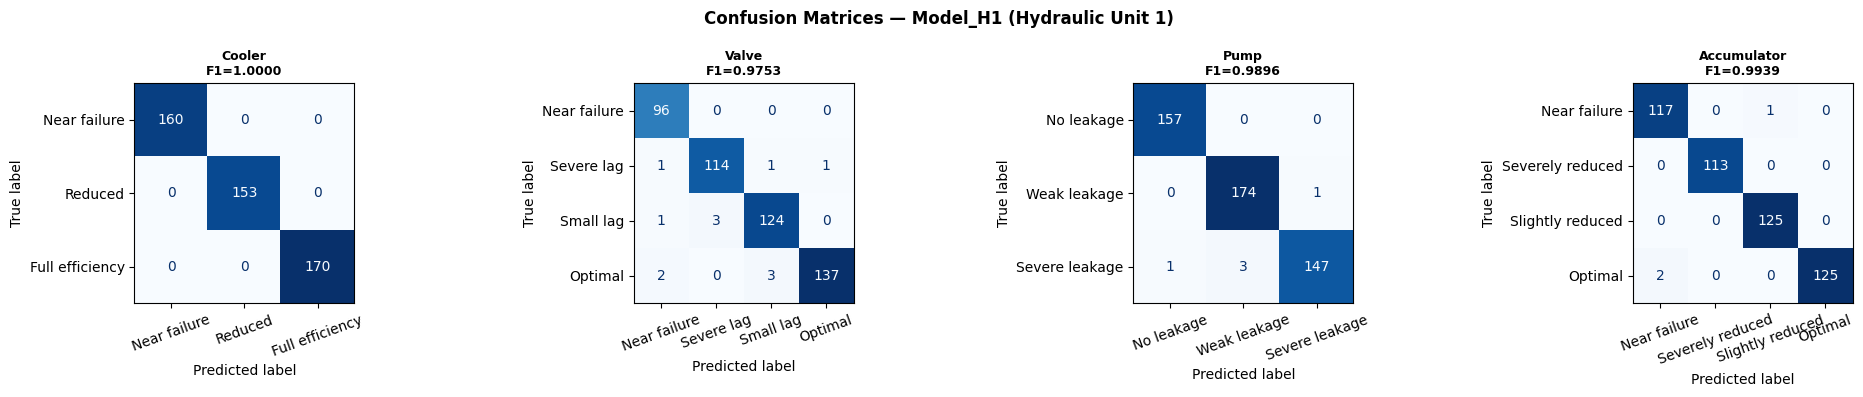

Saved: Model_H1_confusion_matrices.png


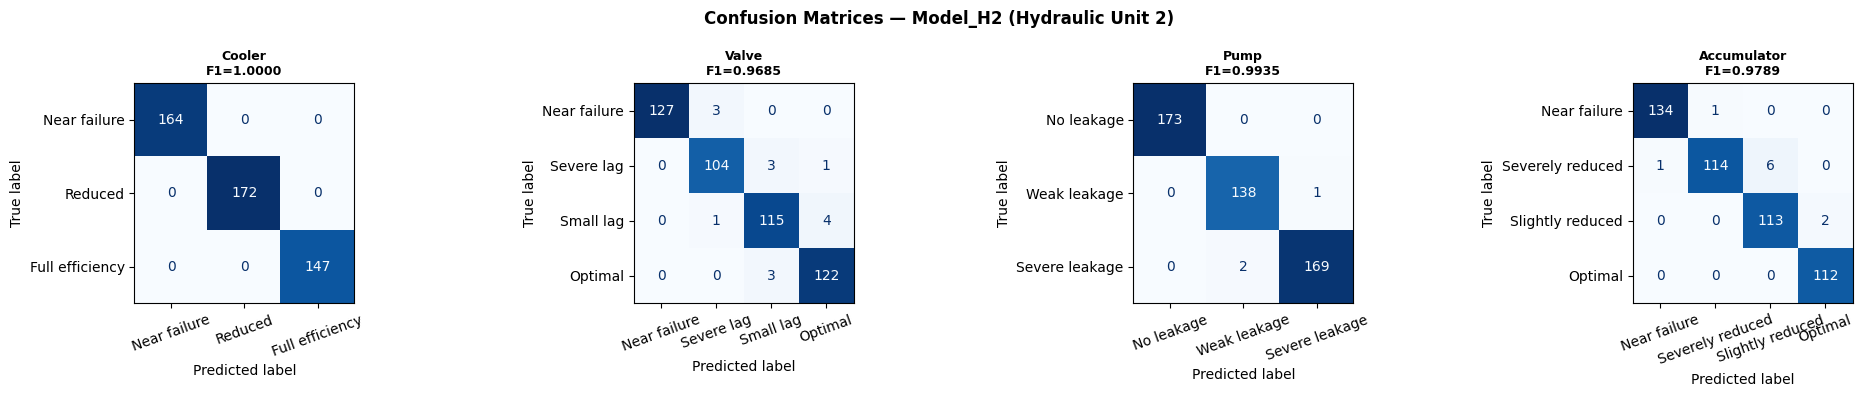

Saved: Model_H2_confusion_matrices.png


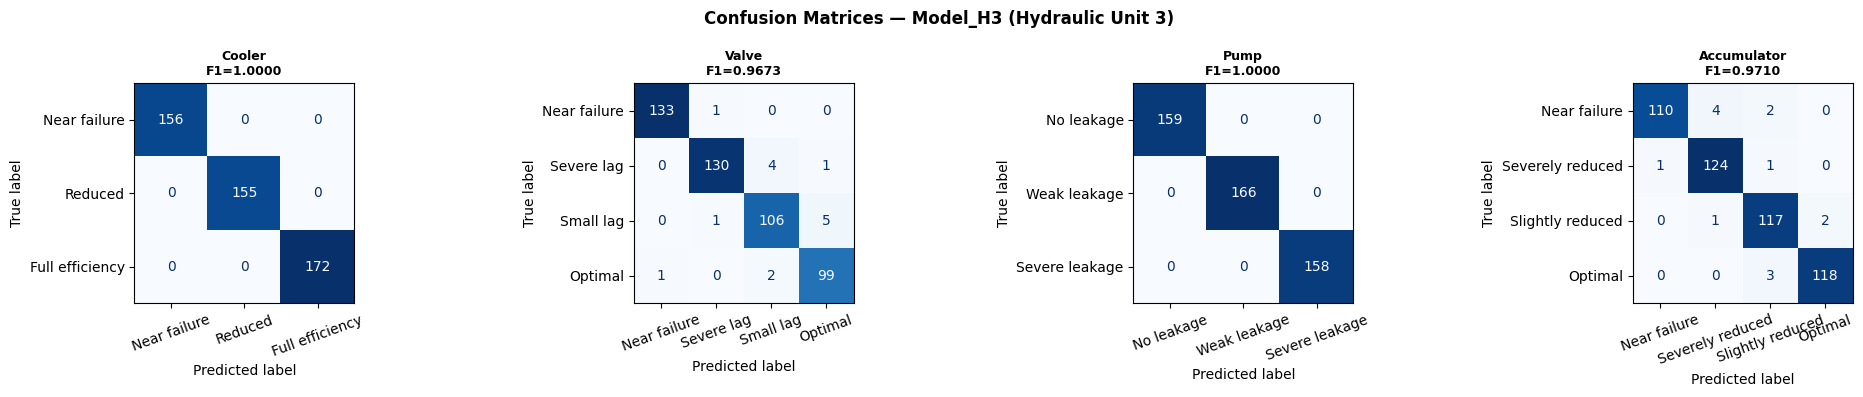

Saved: Model_H3_confusion_matrices.png


In [12]:
for model_name, r in loo_results.items():
    fig, axes = plt.subplots(1, 4, figsize=(20, 4))
    fig.suptitle(f'Confusion Matrices — {model_name} ({r["unit"]})',
                 fontsize=12, fontweight='bold')

    for ax, component in zip(axes, COMPONENTS):
        le      = encoders[component]
        res     = r['results'][component]
        present = sorted(set(res['y_val']) | set(res['val_pred']))
        names   = [COMPONENT_LABELS[component].get(int(le.classes_[i]), str(le.classes_[i]))
                   for i in present if i < len(le.classes_)]
        cm   = confusion_matrix(res['y_val'], res['val_pred'], labels=present)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=names)
        disp.plot(ax=ax, colorbar=False, cmap='Blues')
        ax.set_title(f'{component.capitalize()}\nF1={res["val_f1"]:.4f}',
                     fontweight='bold', fontsize=9)
        ax.tick_params(axis='x', rotation=20)

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f'{model_name}_confusion_matrices.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {model_name}_confusion_matrices.png')

---
## 9. Save Model Bundles

Each bundle is saved as a pickle file and contains everything the FastAPI backend needs for inference: the four component models, the scaler, the label encoders, and the feature name list (order matters at inference time).

In [13]:
for model_name, r in loo_results.items():
    bundle = {
        'model_name':       model_name,
        'unit':             r['unit'],
        'component_models': r['models'],        # dict: component -> XGBClassifier
        'scaler':           r['scaler'],         # StandardScaler fitted on training data
        'encoders':         encoders,            # dict: component -> LabelEncoder
        'feature_names':    FEATURE_NAMES,       # ordered list — must match inference order
        'components':       COMPONENTS,
        'component_labels': COMPONENT_LABELS,
        'val_n_cycles':     len(r['val_idx']),
        'results': {
            c: {
                'val_acc': r['results'][c]['val_acc'],
                'val_f1':  r['results'][c]['val_f1'],
            } for c in COMPONENTS
        }
    }
    out = OUTPUT_DIR / f'{model_name}_bundle.pkl'
    with open(out, 'wb') as f:
        pickle.dump(bundle, f)
    print(f'Saved: {out}')

print('\nDeployment map:')
for model_name, r in loo_results.items():
    mean_f1 = np.mean([r['results'][c]['val_f1'] for c in COMPONENTS])
    print(f'  {model_name}_bundle.pkl  ->  {r["unit"]}  (mean macro-F1={mean_f1:.4f})')

Saved: results\hydraulic_classifier\Model_H1_bundle.pkl
Saved: results\hydraulic_classifier\Model_H2_bundle.pkl
Saved: results\hydraulic_classifier\Model_H3_bundle.pkl

Deployment map:
  Model_H1_bundle.pkl  ->  Hydraulic Unit 1  (mean macro-F1=0.9897)
  Model_H2_bundle.pkl  ->  Hydraulic Unit 2  (mean macro-F1=0.9852)
  Model_H3_bundle.pkl  ->  Hydraulic Unit 3  (mean macro-F1=0.9846)
